<a href="https://colab.research.google.com/github/fabrito2006/Laboratorio-5-MID/blob/develop/Laboratorio_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 05 - Mineria de Datos
## Alumno: Torres Alvaradao Fabricio Ismael
## Ciclo y carrera: 5C28A

## 1. Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28original%29) y utilizando las librerías de Python que se indican, haga lo siguiente:

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# Concat data
data = pd.concat([X, y], axis=1)

### a. Por medio de la librería ‘Pandas’, lea la base de datos, separe las variables numéricas de las no numéricas tomando en cuenta la información que se encuentra en el repositorio, calcule sus estadísticos descriptivos y halle la matriz de correlación.

In [4]:
# Leemos la base de datos
data.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [5]:
# Informacion de variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [6]:
# Convertimos la variable "Class" en tipo factor
data['Class'] = data['Class'].astype('category')

# Verificamos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Clump_thickness              699 non-null    int64   
 1   Uniformity_of_cell_size      699 non-null    int64   
 2   Uniformity_of_cell_shape     699 non-null    int64   
 3   Marginal_adhesion            699 non-null    int64   
 4   Single_epithelial_cell_size  699 non-null    int64   
 5   Bare_nuclei                  683 non-null    float64 
 6   Bland_chromatin              699 non-null    int64   
 7   Normal_nucleoli              699 non-null    int64   
 8   Mitoses                      699 non-null    int64   
 9   Class                        699 non-null    category
dtypes: category(1), float64(1), int64(8)
memory usage: 50.1 KB


In [7]:
# Separamos las variables numericas
data_numeric = data.select_dtypes(include=['float64', 'int64'])
data_numeric.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


In [8]:
# Estadísticos descriptivos
data_numeric.describe()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [9]:
# Matriz de correlación
data_numeric.corr()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
Clump_thickness,1.000000,0.644913,0.654589,0.486356,0.521816,0.593091,0.558428,0.535835,0.350034
Uniformity_of_cell_size,0.644913,1.000000,0.906882,0.705582,0.751799,0.691709,0.755721,0.722865,0.458693
Uniformity_of_cell_shape,0.654589,0.906882,1.000000,0.683079,0.719668,0.713878,0.735948,0.719446,0.438911
Marginal_adhesion,0.486356,0.705582,0.683079,1.000000,0.599599,0.670648,0.666715,0.603352,0.417633
Single_epithelial_cell_size,0.521816,0.751799,0.719668,0.599599,1.000000,0.585716,0.616102,0.628881,0.479101
Bare_nuclei,0.593091,0.691709,0.713878,0.670648,0.585716,1.000000,0.680615,0.584280,0.339210
Bland_chromatin,0.558428,0.755721,0.735948,0.666715,0.616102,0.680615,1.000000,0.665878,0.344169
Normal_nucleoli,0.535835,0.722865,0.719446,0.603352,0.628881,0.584280,0.665878,1.000000,0.428336
Mitoses,0.350034,0.458693,0.438911,0.417633,0.479101,0.339210,0.344169,0.428336,1.000000


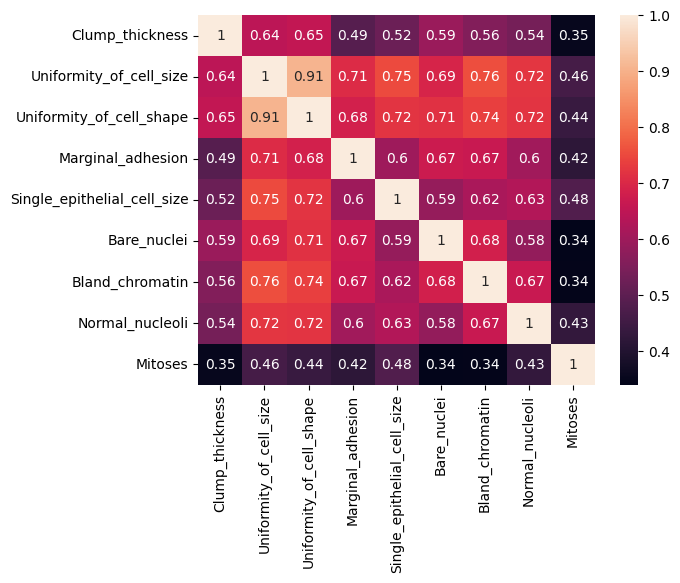

In [10]:
# Graficamos la matriz de correlación
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data_numeric.corr(), annot=True)
plt.show()

### b. Por medio de la librería ‘Matplotlib’, elabore histogramas, gráficos de densidad, box plot y diagramas de dispersión incluyendo diversos parámetros para estos.

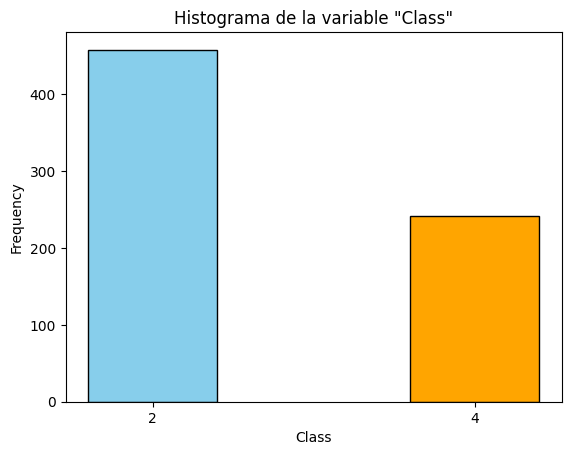

In [11]:
# Histograma de la variable class
colors = ['skyblue', 'orange']
labels = ['Clase 2', 'Clase 4']
counts = data['Class'].value_counts().sort_index()
x_vals = counts.index
y_vals = counts.values
plt.bar(x_vals, y_vals, color=colors, edgecolor='black')

plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Histograma de la variable "Class"')

plt.xticks(x_vals)
plt.show()

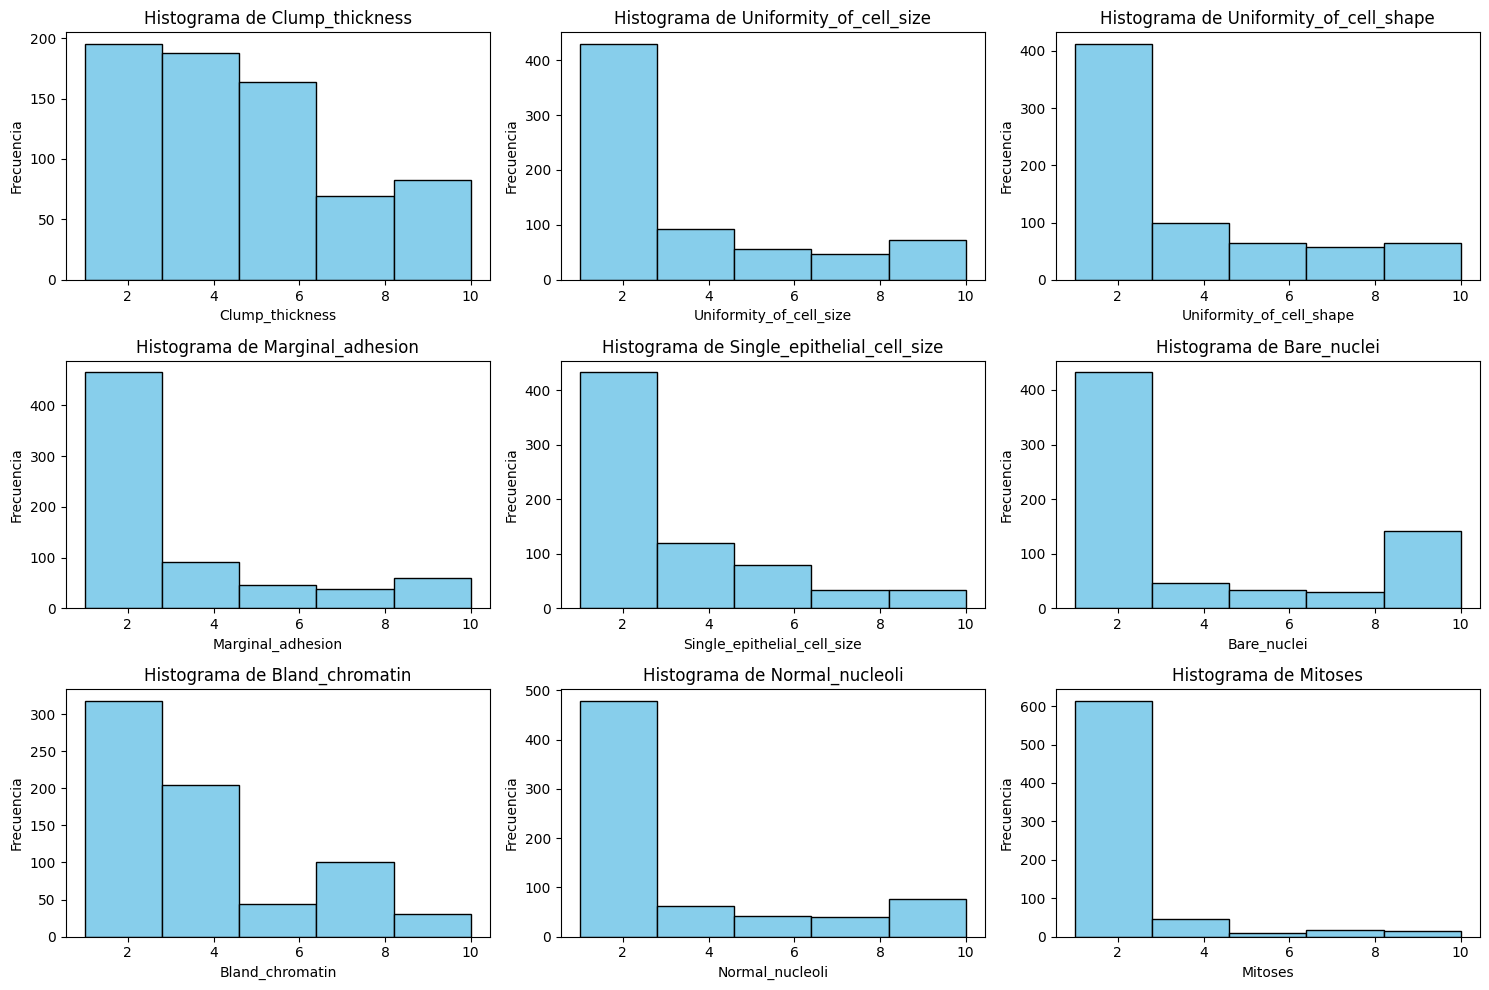

In [12]:
variables = data_numeric.columns.tolist()
plt.figure(figsize=(15, 10))
for i, var in enumerate(variables):
    plt.subplot(3, 3, i+1)
    plt.hist(data[var], bins=5, edgecolor='black', color='skyblue')
    plt.title(f'Histograma de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


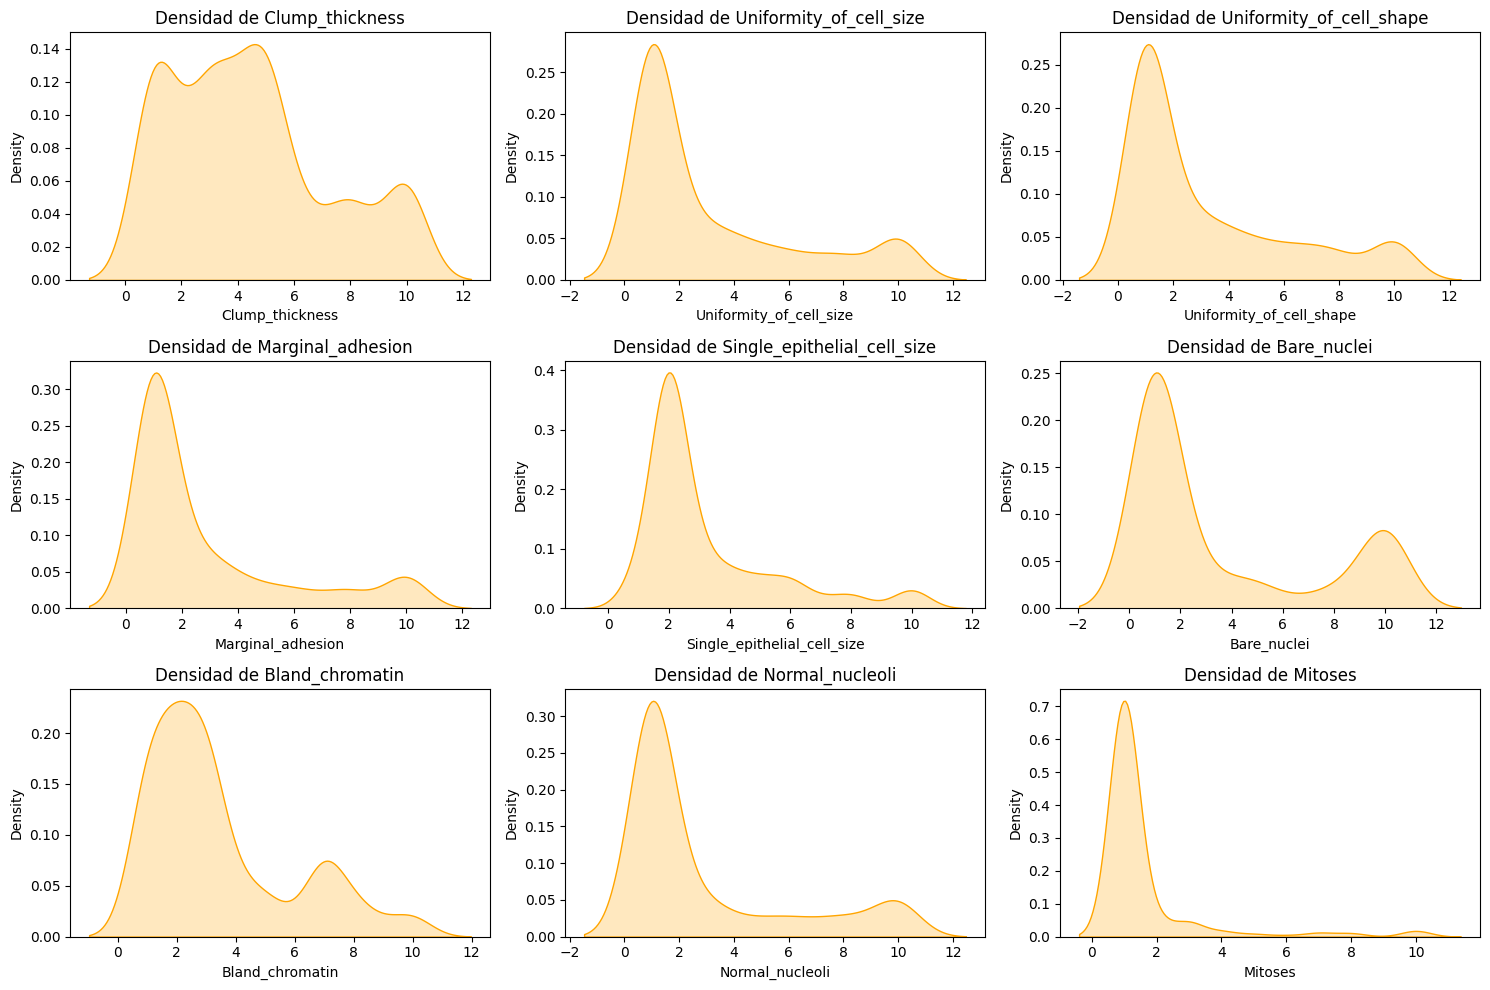

In [13]:
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, var in enumerate(variables):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(data[var], fill=True, color='orange')
    plt.title(f'Densidad de {var}')
    plt.xlabel(var)

plt.tight_layout()
plt.show()

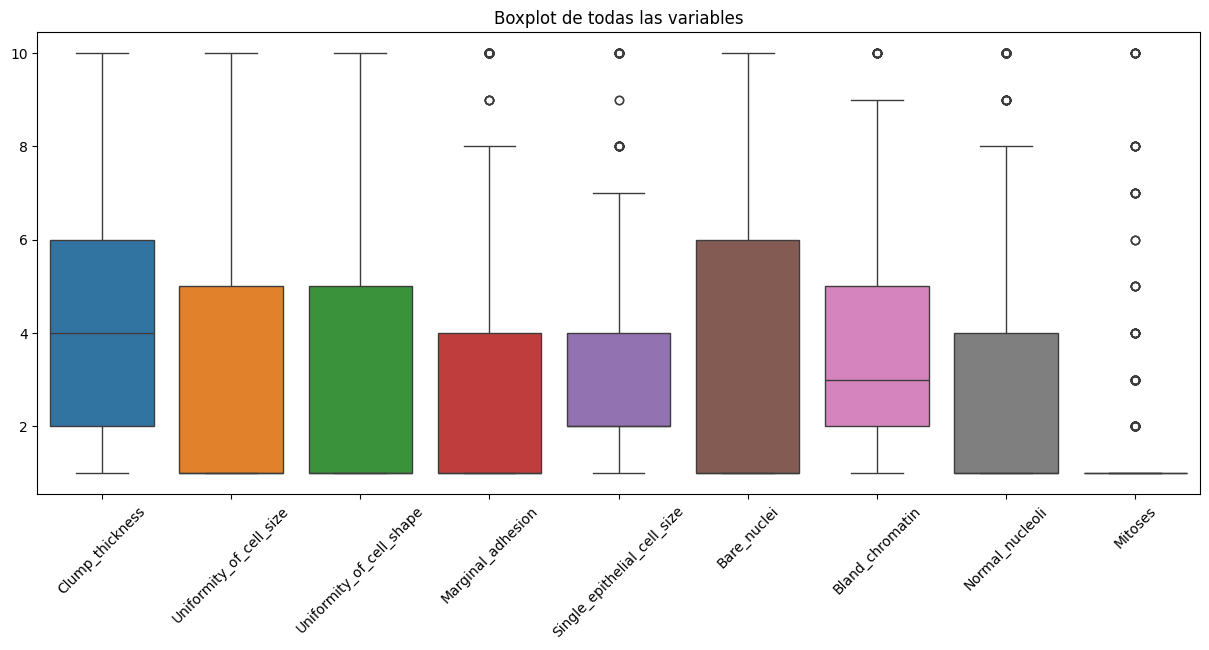

In [14]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=data[variables])
plt.title("Boxplot de todas las variables")
plt.xticks(rotation=45)
plt.show()

### c. Utilice la librería ‘Scikit-learn’ para separar la información en datos de entrenamiento y prueba. Además, implemente un modelo k-NN con dicha información, realice pronósticos y mida la precisión para los datos de entrenamiento y prueba.

In [15]:
# Limpiamos datos nulos
data = data.dropna()

# Seleccionamos de vuelta los datos numericos
data_numeric = data.select_dtypes(include=['float64', 'int64'])

# Verificamos datos nulos
data_numeric.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,0
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [17]:
X = data_numeric
y = data['Class']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [20]:
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Precisión en datos de entrenamiento: {acc_train:.2f}")
print(f"Precisión en datos de prueba: {acc_test:.2f}")

Precisión en datos de entrenamiento: 0.98
Precisión en datos de prueba: 0.96
